# Video Games Sales: Exploratory Data Analysis & Ingestion Preparation

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
import warnings

sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (10, 5)

warnings.filterwarnings("ignore")

## 1. Data Ingestion

In [4]:
data_path = "C:/Users/Administrator/Downloads/New folder/VideoGames_Sales.xlsx"
df = pd.read_excel(data_path)
df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")
df.head()

,title,console,genre,publisher,developer,critic_score,total_sales(mil),na_sales(mil),jp_sales(mil),pal_sales(mil),other_sales(mil),release_date
0,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,20.32,6.37,0.99,9.85,3.12,2013-09-17
1,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,6.06,0.60,9.71,3.02,2014-11-18
2,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,16.15,8.41,0.47,5.49,1.78,2002-10-28
3,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,NaN,15.86,9.06,0.06,5.33,1.42,2013-09-17
4,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1,15.09,6.18,0.41,6.05,2.44,2015-11-06


## 2. Data Profiling and Inspection

In [6]:
print(f"Dataset Dimensions: {df.shape[0]} rows, {df.shape[1]} columns\n")
df.info(memory_usage="deep")

Dataset Dimensions: 64016 rows, 12 columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64016 entries, 0 to 64015
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   title             64016 non-null  object        
 1   console           64016 non-null  object        
 2   genre             64016 non-null  object        
 3   publisher         64016 non-null  object        
 4   developer         63999 non-null  object        
 5   critic_score      6678 non-null   float64       
 6   total_sales(mil)  18922 non-null  float64       
 7   na_sales(mil)     12637 non-null  float64       
 8   jp_sales(mil)     6726 non-null   float64       
 9   pal_sales(mil)    12824 non-null  float64       
 10  other_sales(mil)  15128 non-null  float64       
 11  release_date      56965 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(6), object(5)
memory usage: 21.8 MB


In [7]:
df.describe()

,critic_score,total_sales(mil),na_sales(mil),jp_sales(mil),pal_sales(mil),other_sales(mil),release_date
count,6678.000000,18922.000000,12637.000000,6726.000000,12824.000000,15128.000000,56965
mean,7.220440,0.349113,0.264740,0.102281,0.149472,0.043041,2006-11-14 06:33:03.491617792
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1971-12-03 00:00:00
25%,6.400000,0.030000,0.050000,0.020000,0.010000,0.000000,2001-03-28 00:00:00
50%,7.500000,0.120000,0.120000,0.040000,0.040000,0.010000,2008-09-16 00:00:00
75%,8.300000,0.340000,0.280000,0.120000,0.140000,0.030000,2012-12-27 00:00:00
max,10.000000,20.320000,9.760000,2.130000,9.850000,3.120000,2024-12-31 00:00:00
std,1.457066,0.807462,0.494787,0.168811,0.392653,0.126643,NaN


In [65]:
df.describe(include='object')

,title,console,genre,publisher,developer,dominant_region,publisher_group
count,64016,64016,64016,64016,63999,18922,64016
unique,39798,81,20,3383,8862,4,2
top,Plants vs. Zombies,PC,Misc,Unknown,Unknown,NA,Other Publisher
freq,17,12617,9304,8842,4435,10755,41328


### 2.1 Missing Values Analysis

In [83]:
quality_report = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.values,
    "Missing Values": df.isnull().sum().values,
    "Missing %": round((df.isnull().sum() / len(df)) * 100, 2)
})

quality_report.sort_values(by="Missing %", ascending=False)

,Column,Data Type,Missing Values,Missing %
critic_category,critic_category,category,57338,89.57
critic_score,critic_score,float64,57338,89.57
jp_sales_mil,jp_sales_mil,float64,57290,89.49
na_sales_mil,na_sales_mil,float64,51379,80.26
pal_sales_mil,pal_sales_mil,float64,51192,79.97
other_sales_mil,other_sales_mil,float64,48888,76.37
sales_category,sales_category,category,45094,70.44
total_sales_mil,total_sales_mil,float64,45094,70.44
dominant_region,dominant_region,object,45094,70.44
release_date,release_date,datetime64[ns],7051,11.01


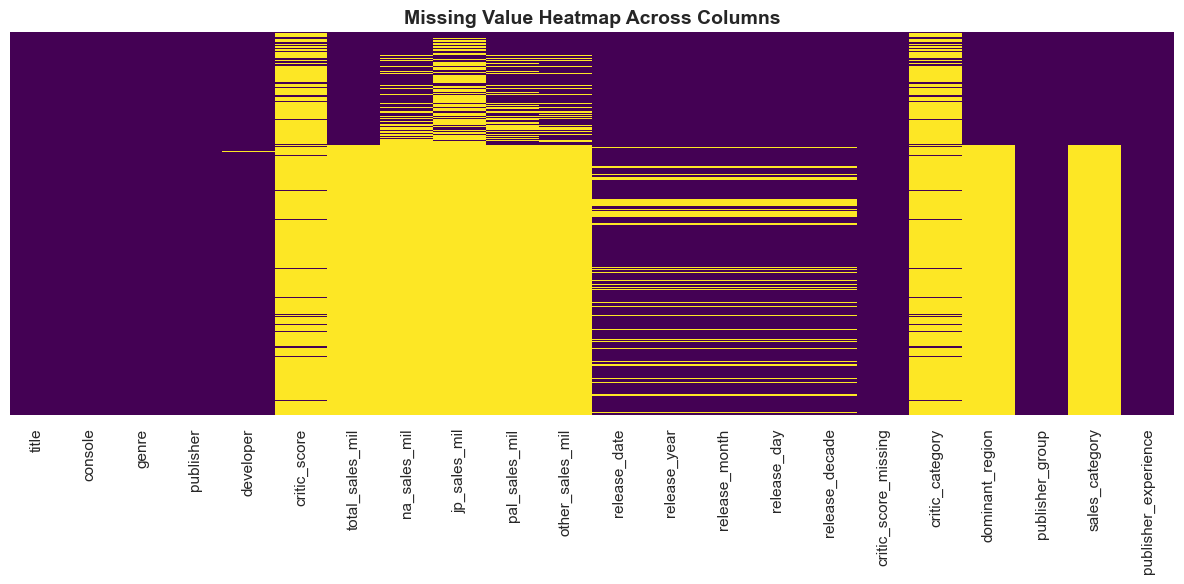

In [85]:
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap="viridis")
plt.title("Missing Value Heatmap Across Columns", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### 2.2 Duplicate Record Profiling

In [88]:
duplicate_full = df.duplicated().sum()
duplicate_title_console = df.duplicated(subset=['title', 'console']).sum()

print(f"Exact Duplicate Rows (All Columns): {duplicate_full}")
print(f"Duplicate Games on (Title, Console) Combination: {duplicate_title_console}")

Exact Duplicate Rows (All Columns): 21
Duplicate Games on (Title, Console) Combination: 225


In [90]:
df[df.duplicated(subset=['title', 'console'], keep=False)].sort_values(by="title").head(10)

,title,console,genre,publisher,developer,critic_score,total_sales_mil,na_sales_mil,jp_sales_mil,pal_sales_mil,...,release_year,release_month,release_day,release_decade,critic_score_missing,critic_category,dominant_region,publisher_group,sales_category,publisher_experience
32538,Absolute Chess,DSiW,Misc,Unknown,Tasuke,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,1,NaN,NaN,Top Publisher,NaN,8842
32537,Absolute Chess,DSiW,Misc,Tasuke,Tasuke,NaN,NaN,NaN,NaN,NaN,...,2010.0,8.0,9.0,2010.0,1,NaN,NaN,Other Publisher,NaN,41
56164,Ace Combat 5: The Unsung War,PS2,Simulation,Namco,Project ACES,8.0,NaN,NaN,NaN,NaN,...,2004.0,10.0,25.0,2000.0,0,Good,NaN,Other Publisher,NaN,458
55926,Ace Combat 5: The Unsung War,PS2,Simulation,Namco,Namco,NaN,NaN,NaN,NaN,NaN,...,2004.0,10.0,25.0,2000.0,1,NaN,NaN,Other Publisher,NaN,458
17417,Adventure Time: The Secret of the Nameless Kin...,X360,Action-Adventure,Little Orbit,Way Forward,NaN,0.01,0.01,NaN,NaN,...,2014.0,11.0,18.0,2010.0,1,NaN,NA,Other Publisher,Low,58
12460,Adventure Time: The Secret of the Nameless Kin...,X360,Adventure,Little Orbit,WayForward Technologies,NaN,0.06,0.00,NaN,0.05,...,2014.0,10.0,18.0,2010.0,1,NaN,PAL,Other Publisher,Medium,58
48467,Akaneiro: Demon Hunters,PC,Role-Playing,Spicy Horse,Spicy Horse,NaN,NaN,NaN,NaN,NaN,...,2013.0,1.0,31.0,2010.0,1,NaN,NaN,Other Publisher,NaN,10
32645,Akaneiro: Demon Hunters,PC,Misc,Spicy Horse,Unknown,NaN,NaN,NaN,NaN,NaN,...,2013.0,6.0,13.0,2010.0,1,NaN,NaN,Other Publisher,NaN,10
13461,Akko ni Omakase! Brain Shock,DS,Misc,Taito,Taito,NaN,0.04,NaN,0.04,NaN,...,2006.0,12.0,7.0,2000.0,1,NaN,JP,Other Publisher,Medium,247
13536,Akko ni Omakase! Brain Shock,DS,Misc,Taito,Taito Corporation,NaN,0.04,NaN,0.04,NaN,...,2006.0,12.0,7.0,2000.0,1,NaN,JP,Other Publisher,Medium,247


## 3. Data Cleaning & Column Standardization

In [93]:
df.columns = (
    df.columns
    .str.lower()
    .str.strip()
    .str.replace(" ", "_")
)

df = df.rename(columns={
    "total_sales(mil)": "total_sales_mil",
    "na_sales(mil)": "na_sales_mil",
    "jp_sales(mil)": "jp_sales_mil",
    "pal_sales(mil)": "pal_sales_mil",
    "other_sales(mil)": "other_sales_mil",
})

print("Standardized Column Names:")
print(df.columns.tolist())

Standardized Column Names:
['title', 'console', 'genre', 'publisher', 'developer', 'critic_score', 'total_sales_mil', 'na_sales_mil', 'jp_sales_mil', 'pal_sales_mil', 'other_sales_mil', 'release_date', 'release_year', 'release_month', 'release_day', 'release_decade', 'critic_score_missing', 'critic_category', 'dominant_region', 'publisher_group', 'sales_category', 'publisher_experience']


In [95]:
sales_cols = ["total_sales_mil", "na_sales_mil", "jp_sales_mil", "pal_sales_mil", "other_sales_mil"]

print("Negative values count in sales columns:")
for col in sales_cols:
    neg_count = (df[col] < 0).sum()
    print(f"  {col}: {neg_count}")

invalid_critic = ((df["critic_score"] < 0) | (df["critic_score"] > 10)).sum()
print(f"\nInvalid critic scores (not in range [0, 10]): {invalid_critic}")

Negative values count in sales columns:
  total_sales_mil: 0
  na_sales_mil: 0
  jp_sales_mil: 0
  pal_sales_mil: 0
  other_sales_mil: 0

Invalid critic scores (not in range [0, 10]): 0


### 3.1 Outlier Analysis on Total Sales

In [98]:
Q1 = df["total_sales_mil"].quantile(0.25)
Q3 = df["total_sales_mil"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df["total_sales_mil"] < lower_bound) | (df["total_sales_mil"] > upper_bound)]

print(f"25th Percentile (Q1): {Q1}")
print(f"75th Percentile (Q3): {Q3}")
print(f"IQR: {IQR}")
print(f"Outlier Thresholds: [{lower_bound:.2f}, {upper_bound:.2f}]")
print(f"Number of Outliers: {outliers.shape[0]} (out of {df.shape[0]} games, or {outliers.shape[0]/df.shape[0]*100:.2f}%)")

25th Percentile (Q1): 0.03
75th Percentile (Q3): 0.34
IQR: 0.31000000000000005
Outlier Thresholds: [-0.44, 0.81]
Number of Outliers: 1963 (out of 64016 games, or 3.07%)


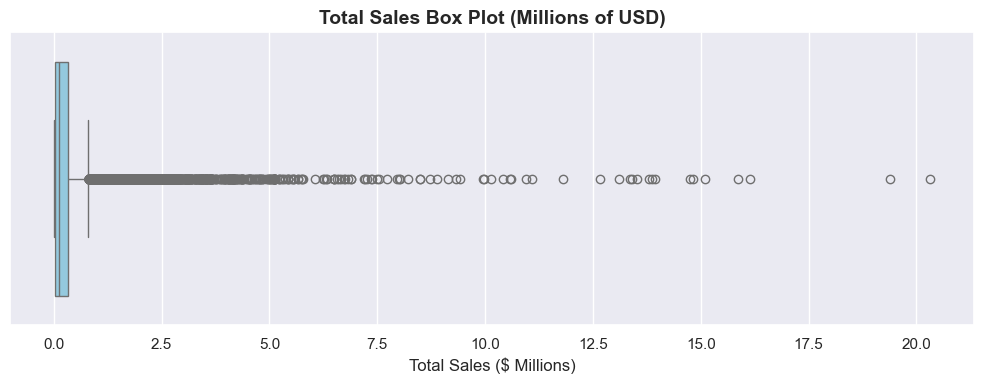

In [100]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df["total_sales_mil"], color="skyblue")
plt.title("Total Sales Box Plot (Millions of USD)", fontsize=14, fontweight="bold")
plt.xlabel("Total Sales ($ Millions)")
plt.tight_layout()
plt.show()

## 4. Feature Engineering

In [187]:
# Date Components
df['release_year'] = df['release_date'].dt.year
df['release_month'] = df['release_date'].dt.month
df['release_day'] = df['release_date'].dt.day
df['release_decade'] = (df['release_year'] // 10) * 10

# Critic score Missingness Flag
df["critic_score_missing"] = df["critic_score"].isnull().astype(int)

# Critic Score Binning
df["critic_category"] = pd.qcut(
    df["critic_score"],
    q=4,
    labels=["Poor", "Average", "Good", "Excellent"]
)

# Dominant Region
regions = ["na_sales_mil", "jp_sales_mil", "pal_sales_mil", "other_sales_mil"]
df["dominant_region"] = (
    df[regions]
    .idxmax(axis=1)
    .str.replace("_sales_mil", "", regex=False)
    .str.upper()
)

# Publisher Grouping
top_publishers = df["publisher"].value_counts().head(10).index
df["publisher_group"] = np.where(df["publisher"].isin(top_publishers), "Top Publisher", "Other Publisher")

# Sales Categories
df["sales_category"] = pd.qcut(
    df["total_sales_mil"],
    q=4,
    labels=["Low", "Medium", "High", "Blockbuster"]
)

# Publisher Experience
publisher_experience = df.groupby("publisher").size()
df["publisher_experience"] = df["publisher"].map(publisher_experience)

# Display a sample of the engineered features
df[["title", "release_year", "critic_category", "dominant_region", "publisher_group", "sales_category"]].head(5)


,title,release_year,critic_category,dominant_region,publisher_group,sales_category
0,Grand Theft Auto V,2013.0,Excellent,PAL,Other Publisher,Blockbuster
1,Grand Theft Auto V,2014.0,Excellent,PAL,Other Publisher,Blockbuster
2,Grand Theft Auto: Vice City,2002.0,Excellent,NA,Other Publisher,Blockbuster
3,Grand Theft Auto V,2013.0,NaN,NA,Other Publisher,Blockbuster
4,Call of Duty: Black Ops 3,2015.0,Good,NA,Top Publisher,Blockbuster


In [185]:
df[["title", "release_year", "critic_category", "dominant_region","publisher", "publisher_experience", "publisher_group", "sales_category"]].head(15)

,title,release_year,critic_category,dominant_region,publisher,publisher_experience,publisher_group,sales_category
0,Grand Theft Auto V,2013.0,Excellent,PAL,Rockstar Games,180,Other Publisher,Blockbuster
1,Grand Theft Auto V,2014.0,Excellent,PAL,Rockstar Games,180,Other Publisher,Blockbuster
2,Grand Theft Auto: Vice City,2002.0,Excellent,NA,Rockstar Games,180,Other Publisher,Blockbuster
3,Grand Theft Auto V,2013.0,NaN,NA,Rockstar Games,180,Other Publisher,Blockbuster
4,Call of Duty: Black Ops 3,2015.0,Good,NA,Activision,1582,Top Publisher,Blockbuster
5,Call of Duty: Modern Warfare 3,2011.0,Excellent,NA,Activision,1582,Top Publisher,Blockbuster
6,Call of Duty: Black Ops,2010.0,Excellent,NA,Activision,1582,Top Publisher,Blockbuster
7,Red Dead Redemption 2,2018.0,Excellent,PAL,Rockstar Games,180,Other Publisher,Blockbuster
8,Call of Duty: Black Ops II,2012.0,Excellent,NA,Activision,1582,Top Publisher,Blockbuster
9,Call of Duty: Black Ops II,2012.0,Good,PAL,Activision,1582,Top Publisher,Blockbuster


### 4.1 Regional Market Profiling

In [209]:
region_profile = df.groupby("dominant_region")["genre"].agg(
    dominant_genre = lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan,
    unique_genre_count = "nunique"
)
region_profile

,dominant_genre,unique_genre_count
dominant_region,,
JP,Adventure,18
NA,Action,19
OTHER,Misc,9
PAL,Sports,18


## 5. Core KPI Dashboard


In [113]:
total_sales_val = df["total_sales_mil"].sum()
total_games_val = df["title"].nunique()
publishers_val = df["publisher"].nunique()
avg_sales_val = df["total_sales_mil"].mean()
avg_score_val = df["critic_score"].mean()

print("=" * 45)
print("       VIDEO GAME INDUSTRY CORE KPIs")
print("=" * 45)
print(f"Total Industry Revenue (Sales):  ${total_sales_val:,.2f}M")
print(f"Total Unique Games Catalog:      {total_games_val:,}")
print(f"Total Unique Publishers:          {publishers_val:,}")
print(f"Average Sales Per Game Release:  ${avg_sales_val:.2f}M")
print(f"Average Rated Game Critic Score: {avg_score_val:.2f}/10")
print("=" * 45)

       VIDEO GAME INDUSTRY CORE KPIs
Total Industry Revenue (Sales):  $6,605.91M
Total Unique Games Catalog:      39,798
Total Unique Publishers:          3,383
Average Sales Per Game Release:  $0.35M
Average Rated Game Critic Score: 7.22/10


## 6. Exploratory Data Analysis & Business Questions

### 6.1 Industry Evolution: Volume and Revenue Trends Over Time

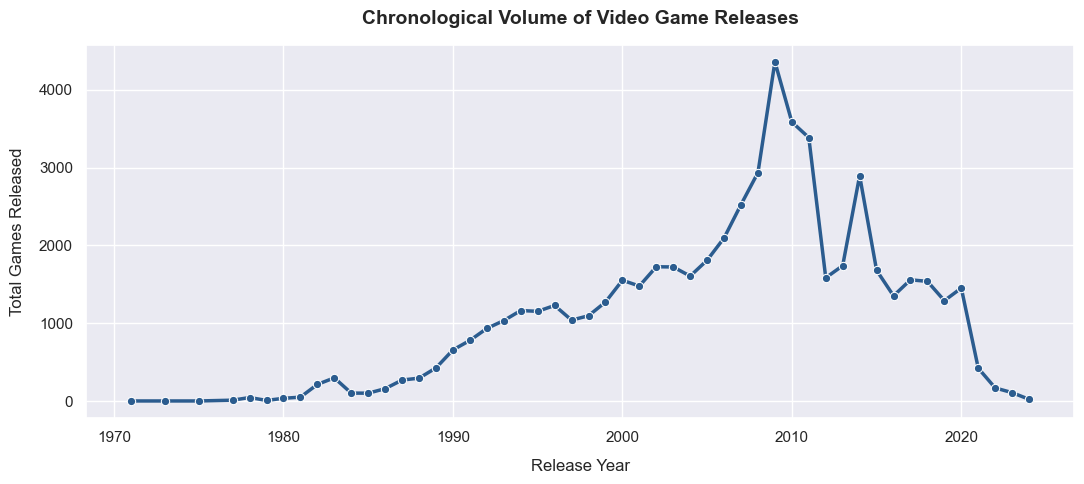

In [29]:

# 1. Annual releases count
yearly_games = df.groupby("release_year").size()

# Plot Volume of Releases over time
plt.figure(figsize=(11, 5))
sns.lineplot(
    x=yearly_games.index, 
    y=yearly_games.values, 
    marker="o", 
    linewidth=2.5, 
    color="#2b5c8f"
)
plt.title("Chronological Volume of Video Game Releases", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Release Year", fontsize=12, labelpad=10)
plt.ylabel("Total Games Released", fontsize=12, labelpad=10)
plt.tight_layout()
plt.savefig("releases_volume_plot.png", dpi=300)
plt.show()



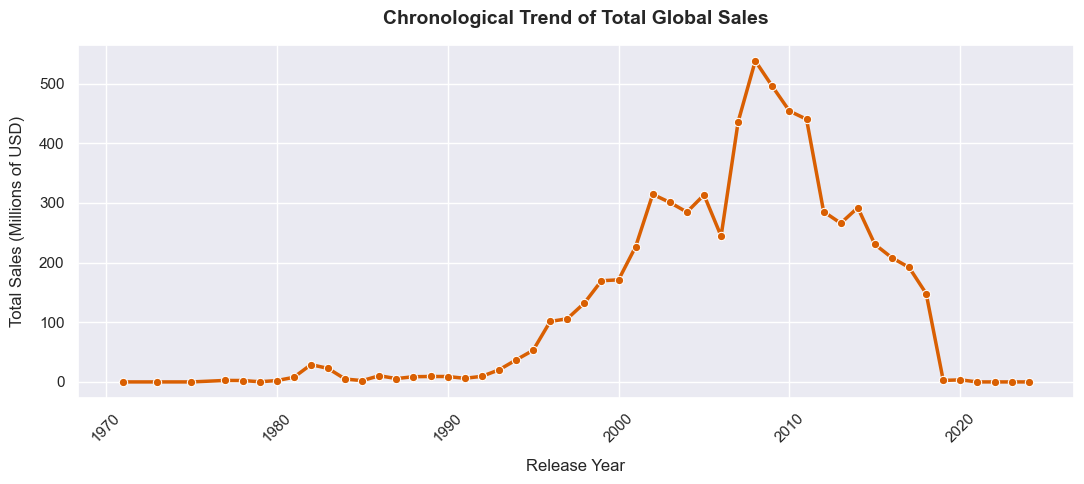

In [30]:

# 2. Annual sales trend
sales_trend = df.groupby("release_year")["total_sales_mil"].sum()

# Plot Total Sales over time
plt.figure(figsize=(11, 5))
sns.lineplot(
    x=sales_trend.index, 
    y=sales_trend.values, 
    marker="o", 
    linewidth=2.5, 
    color="#d95f02"
)
plt.title("Chronological Trend of Total Global Sales", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Release Year", fontsize=12, labelpad=10)
plt.ylabel("Total Sales (Millions of USD)", fontsize=12, labelpad=10)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("sales_trend_plot.png", dpi=300)
plt.show()



### 6.2 Genre Performance: Volume vs. Market Share

In [213]:

genre_sales = df.groupby("genre")["total_sales_mil"].sum().sort_values(ascending=False)

genre_sales 

genre
Sports              1187.51
Action              1125.89
Shooter              995.50
Misc                 557.79
Racing               525.75
Role-Playing         426.80
Platform             349.15
Fighting             341.13
Adventure            325.39
Simulation           300.65
Action-Adventure     148.52
Puzzle               127.28
Strategy             118.31
Music                 51.75
MMO                    9.31
Party                  6.21
Visual Novel           5.78
Sandbox                1.89
Education              0.97
Board Game             0.33
Name: total_sales_mil, dtype: float64

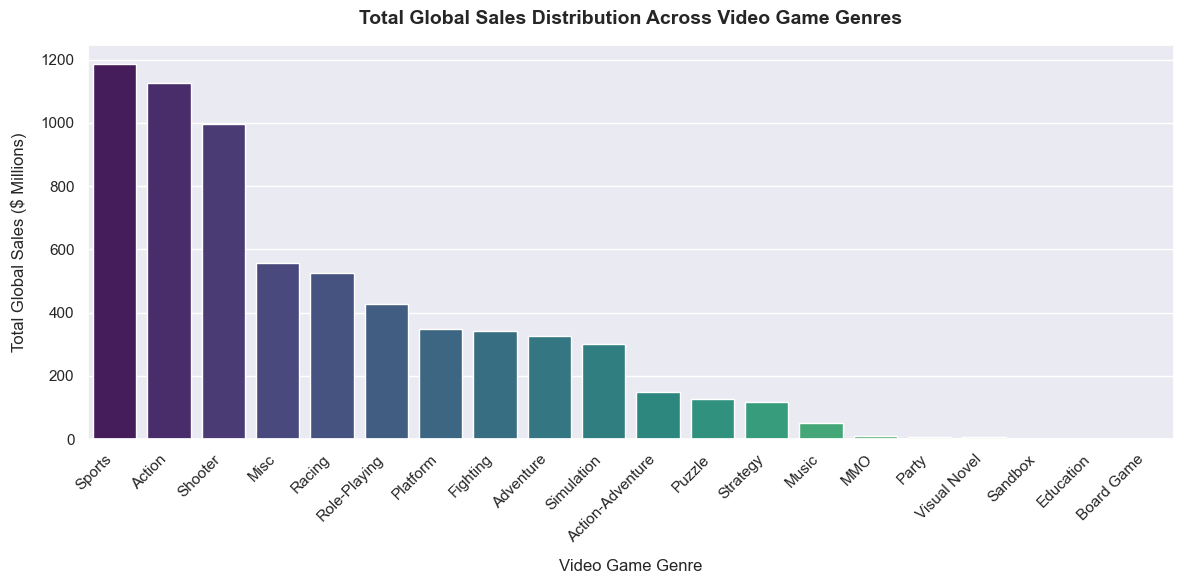

In [221]:

# Total global sales by genre
genre_sales = df.groupby("genre")["total_sales_mil"].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(
    x=genre_sales.index,   
    y=genre_sales.values,  
    palette="viridis"
)
plt.title("Total Global Sales Distribution Across Video Game Genres", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Video Game Genre", fontsize=12, labelpad=10)
plt.ylabel("Total Global Sales ($ Millions)", fontsize=12, labelpad=10)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("genre_sales_plot.png", dpi=300)
plt.show()



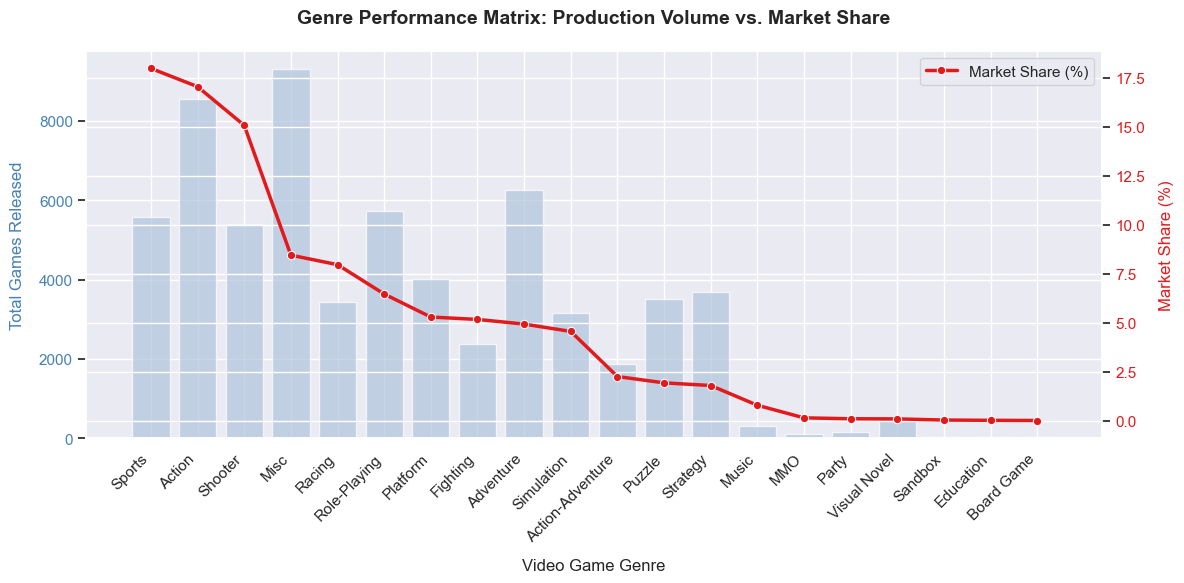

In [33]:

# Genre Performance Matrix (Dual Axis plot: volume vs market share)
genre_kpi = df.groupby("genre").agg(
    total_sales=("total_sales_mil", "sum"),
    avg_sales=("total_sales_mil", "mean"),
    games=("title", "count")
)
genre_kpi["market_share"] = (genre_kpi["total_sales"] / genre_kpi["total_sales"].sum()) * 100
genre_kpi = genre_kpi.sort_values(by="market_share", ascending=False)

fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Volume (Games Count) on Axis 1 (Bars)
ax1.bar(
    genre_kpi.index, 
    genre_kpi["games"], 
    color="#b0c4de", 
    alpha=0.7, 
    label="Volume (Games Count)"
)
ax1.set_xlabel("Video Game Genre", fontsize=12, labelpad=10)
ax1.set_ylabel("Total Games Released", color="#4682b4", fontsize=12, labelpad=10)
ax1.tick_params(axis='y', labelcolor="#4682b4")
ax1.set_xticks(range(len(genre_kpi.index)))
ax1.set_xticklabels(genre_kpi.index, rotation=45, ha='right')

# Instantiate Axis 2 (Market Share Percentage Line)
ax2 = ax1.twinx()
sns.lineplot(
    x=genre_kpi.index, 
    y=genre_kpi["market_share"], 
    color="#e31a1c", 
    marker="o", 
    linewidth=2.5, 
    label="Market Share (%)",
    ax=ax2
)
ax2.set_ylabel("Market Share (%)", color="#e31a1c", fontsize=12, labelpad=10)
ax2.tick_params(axis='y', labelcolor="#e31a1c")

plt.title("Genre Performance Matrix: Production Volume vs. Market Share", fontsize=14, fontweight="bold", pad=20)
plt.tight_layout()
plt.savefig("genre_kpi_combo_plot.png", dpi=300)
plt.show()



### 6.3 Publisher Dominance and Efficiency

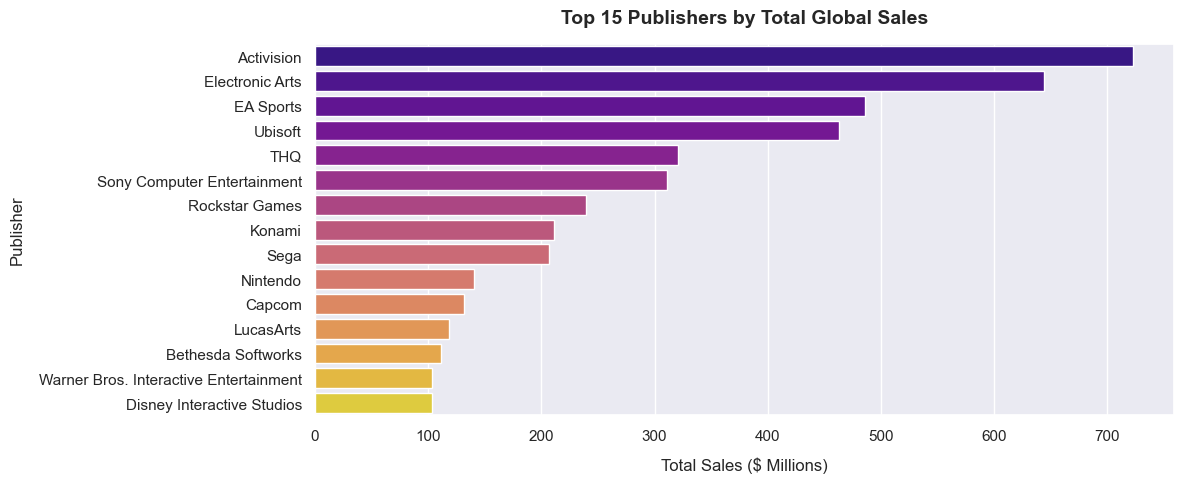

In [35]:

# Publisher metrics
publisher_kpi = df.groupby("publisher").agg(
    total_sales=("total_sales_mil", "sum"),
    games=("title", "count"),
    avg_sales=("total_sales_mil", "mean")
)

# Top 15 publishers by total sales volume
top_pub_total = publisher_kpi.sort_values(by="total_sales", ascending=False).head(15)

plt.figure(figsize=(12, 5))
sns.barplot(
    x=top_pub_total["total_sales"],
    y=top_pub_total.index,
    palette="plasma"
)
plt.title("Top 15 Publishers by Total Global Sales", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Total Sales ($ Millions)", fontsize=12, labelpad=10)
plt.ylabel("Publisher", fontsize=12, labelpad=10)
plt.tight_layout()
plt.show()



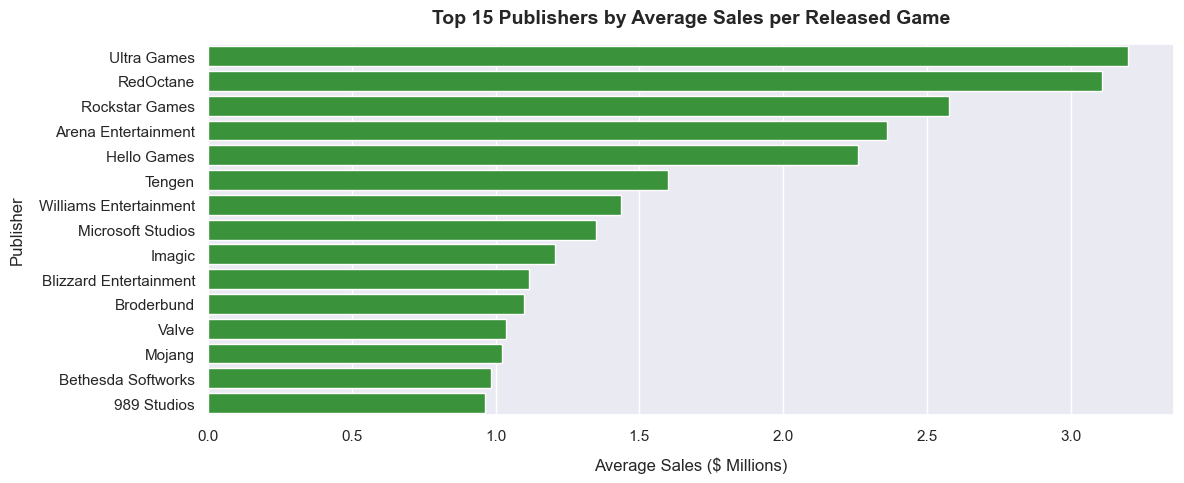

In [36]:

# Top 15 publishers by average sales yield per game
top_pub_avg = publisher_kpi.sort_values(by="avg_sales", ascending=False).head(15)

plt.figure(figsize=(12, 5))
sns.barplot(
    x=top_pub_avg["avg_sales"],
    y=top_pub_avg.index,
    color="#2ca02c"
)
plt.title("Top 15 Publishers by Average Sales per Released Game", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Average Sales ($ Millions)", fontsize=12, labelpad=10)
plt.ylabel("Publisher", fontsize=12, labelpad=10)
plt.tight_layout()
plt.show()



### 6.4 Critic Scores and Sales Correlation

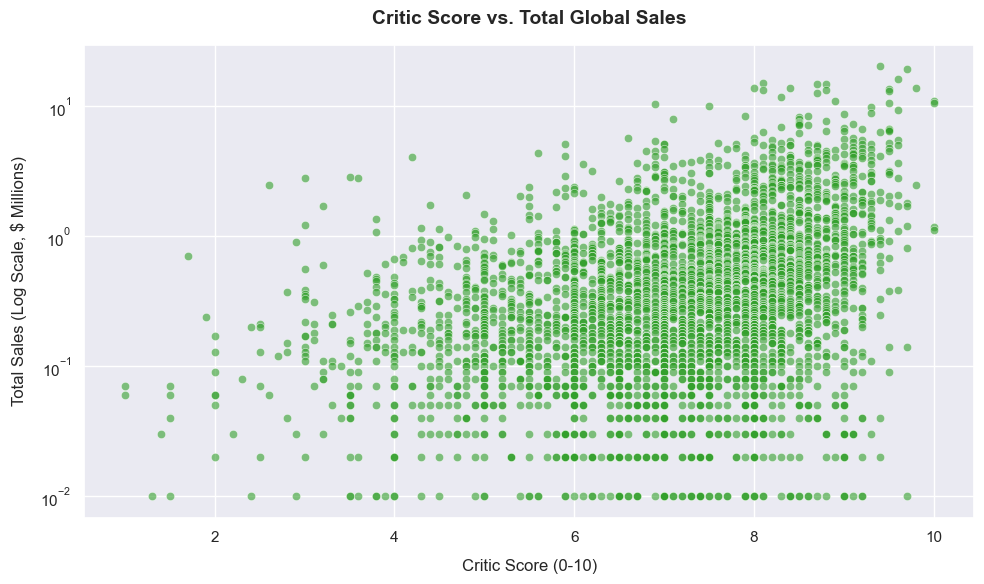

In [38]:

# Scatter plot of critic score vs total sales
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="critic_score",
    y="total_sales_mil",
    alpha=0.6,
    color="#33a02c"
)
plt.title("Critic Score vs. Total Global Sales", fontsize=14, fontweight="bold", pad=15)
plt.yscale('log')
plt.xlabel("Critic Score (0-10)", fontsize=12, labelpad=10)
plt.ylabel("Total Sales (Log Scale, $ Millions)", fontsize=12, labelpad=10)
plt.tight_layout()
plt.show()



In [231]:

# Summary statistics of sales by critic score category
score_analysis = df.groupby("critic_category")["total_sales_mil"].agg(["mean", "median", "count"])
print("Sales Performance (in Millions) by Critic Score Category:")
print(score_analysis)



Sales Performance (in Millions) by Critic Score Category:
                     mean  median  count
critic_category                         
Poor             0.330018   0.180   1137
Average          0.519836   0.260   1218
Good             0.798069   0.425    984
Excellent        1.585921   0.710    787


## Section 7: Statistical Hypothesis Testing

In [41]:

# 1. Pearson Correlation
corr_data = df[["critic_score", "total_sales_mil"]].dropna()
corr_val, p_val_corr = stats.pearsonr(
    corr_data["critic_score"],
    corr_data["total_sales_mil"]
)
print("=" * 50)
print("TEST 1: Pearson Correlation (Quality vs Sales)")
print("=" * 50)
print(f"Correlation Coefficient: {corr_val:.4f}")
print(f"P-value: {p_val_corr}")
if p_val_corr < 0.05:
    print("Conclusion: Reject H0. There is a statistically significant correlation.")
else:
    print("Conclusion: Fail to reject H0. No significant correlation detected.")
print("=" * 50)



TEST 1: Pearson Correlation (Quality vs Sales)
Correlation Coefficient: 0.2812
P-value: 7.847250486870013e-76
Conclusion: Reject H0. There is a statistically significant correlation.


In [42]:

# 2. Two-sample T-test
excellent_sales = df[df["critic_category"]=="Excellent"]["total_sales_mil"].dropna()
average_sales = df[df["critic_category"]=="Average"]["total_sales_mil"].dropna()

t_stat, p_val_t = stats.ttest_ind(
    excellent_sales,
    average_sales,
    equal_var=False
)
print("=" * 50)
print("TEST 2: Two-sample T-test (Excellent vs Average)")
print("=" * 50)
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_val_t}")
if p_val_t < 0.05:
    print("Conclusion: Reject H0. There is a significant difference in sales.")
else:
    print("Conclusion: Fail to reject H0. No significant difference in sales.")
print("=" * 50)



TEST 2: Two-sample T-test (Excellent vs Average)
T-statistic: 11.8776
P-value: 2.3696245140283777e-30
Conclusion: Reject H0. There is a significant difference in sales.


In [43]:

# 3. One-way ANOVA
genre_groups = []
valid_genres = df["genre"].dropna().unique()
for genre in valid_genres:
    genre_groups.append(
        df[df["genre"] == genre]["total_sales_mil"].dropna()
    )

f_stat, p_val_f = stats.f_oneway(*genre_groups)
print("=" * 50)
print("TEST 3: One-way ANOVA (Sales Across Genres)")
print("=" * 50)
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_val_f}")
if p_val_f < 0.05:
    print("Conclusion: Reject H0. Sales vary significantly across genres.")
else:
    print("Conclusion: Fail to reject H0. No significant difference across genres.")
print("=" * 50)



TEST 3: One-way ANOVA (Sales Across Genres)
F-statistic: 30.6802
P-value: 1.279900771715786e-109
Conclusion: Reject H0. Sales vary significantly across genres.


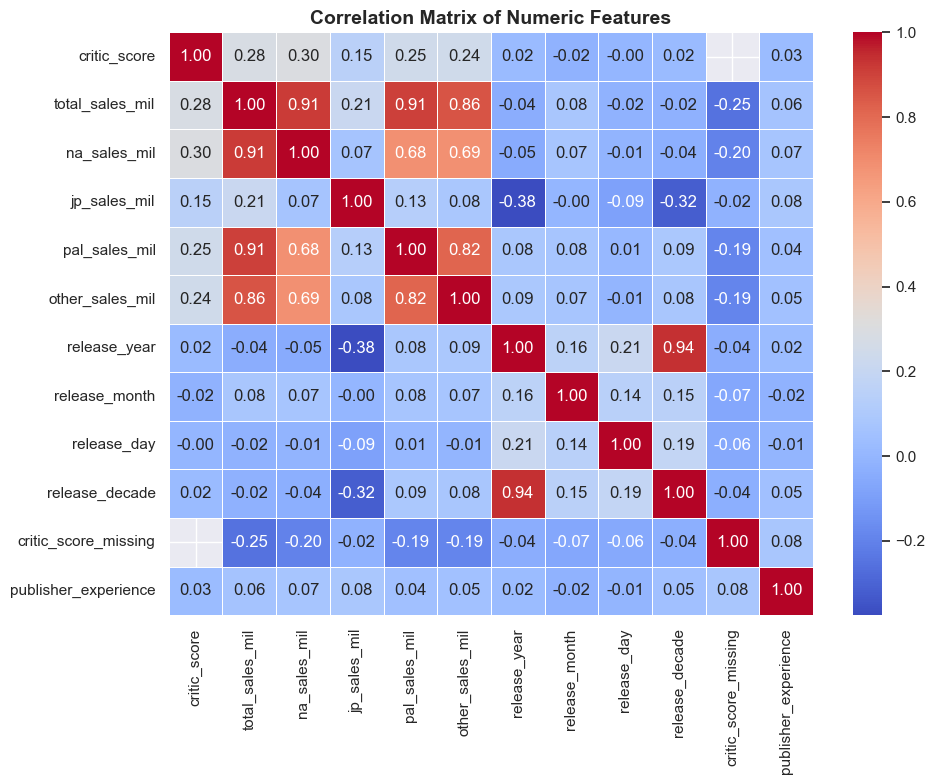

In [44]:

# Correlation Matrix Heatmap
numeric_cols = df.select_dtypes(include=np.number)
corr = numeric_cols.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)
plt.title("Correlation Matrix of Numeric Features", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()



## Section 8: Final Refinement & Export for SQL Database

In [234]:
keep_columns = [
    "title",
    "console",
    "genre",
    "publisher",
    "developer",
    "critic_score",
    "total_sales_mil",
    "na_sales_mil",
    "jp_sales_mil",
    "pal_sales_mil",
    "other_sales_mil",
    "release_date",
]

final_dataset = df[keep_columns].copy()
final_dataset = final_dataset.dropna(subset=["title", "console", "genre", "publisher", "release_date"])
final_dataset = final_dataset.drop_duplicates()

final_dataset["release_year"] = final_dataset["release_date"].dt.year
final_dataset["release_month"] = final_dataset["release_date"].dt.month

final_dataset = final_dataset.sort_values(
    ["total_sales_mil", "critic_score"], 
    ascending=[False, False]
).reset_index(drop=True)

print(f"Final Refined Dataset Shape: {final_dataset.shape[0]} rows, {final_dataset.shape[1]} columns")
print("\nFinal Schema:")
print(list(final_dataset.columns))
print("\nFirst 5 Rows of SQL-Ready Table:")
print(final_dataset.head())

final_output_path = "VideoGames_Sales_refined.csv"
final_dataset.to_csv(final_output_path, index=False)
print(f"\nSuccessfully exported cleaned and structured dataset to '{final_output_path}'")

Final Refined Dataset Shape: 56944 rows, 14 columns

Final Schema:
['title', 'console', 'genre', 'publisher', 'developer', 'critic_score', 'total_sales_mil', 'na_sales_mil', 'jp_sales_mil', 'pal_sales_mil', 'other_sales_mil', 'release_date', 'release_year', 'release_month']

First 5 Rows of SQL-Ready Table:
                         title console    genre       publisher  \
0           Grand Theft Auto V     PS3   Action  Rockstar Games   
1           Grand Theft Auto V     PS4   Action  Rockstar Games   
2  Grand Theft Auto: Vice City     PS2   Action  Rockstar Games   
3           Grand Theft Auto V    X360   Action  Rockstar Games   
4    Call of Duty: Black Ops 3     PS4  Shooter      Activision   

        developer  critic_score  total_sales_mil  na_sales_mil  jp_sales_mil  \
0  Rockstar North           9.4            20.32          6.37          0.99   
1  Rockstar North           9.7            19.39          6.06          0.60   
2  Rockstar North           9.6            16.15

In [103]:
final_dataset.head()

,title,console,genre,publisher,developer,critic_score,total_sales_mil,na_sales_mil,jp_sales_mil,pal_sales_mil,other_sales_mil,release_date,release_year,release_month
0,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,20.32,6.37,0.99,9.85,3.12,2013-09-17,2013,9
1,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,6.06,0.60,9.71,3.02,2014-11-18,2014,11
2,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,16.15,8.41,0.47,5.49,1.78,2002-10-28,2002,10
3,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,NaN,15.86,9.06,0.06,5.33,1.42,2013-09-17,2013,9
4,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1,15.09,6.18,0.41,6.05,2.44,2015-11-06,2015,11


## Connecting to PostgreSQL

In [ ]:
from sqlalchemy import create_engine

username = "------"  # replace with your actual username   
password = "----"  # replace with your actual password  
host = "localhost"             
port = "5432"                  
database = "video_games_sales"     

# Create the connection engine
engine = create_engine(f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}")

# Step 2: Load DataFrame into PostgreSQL
table_name = "vgsales"        # choose any table name
final_dataset.to_sql(table_name, engine, if_exists="replace", index=False)

print(f"Data successfully loaded into table '{table_name}' in database '{database}'.")

Data successfully loaded into table 'vgsales' in database 'video_games_sales'.
